# Suite 02: Standardized TFR LFP 1D Traces per Area and Layer

Plots time-resolved TFR band power traces with shaded error bars ($\pm 2$ SEM) to compare Control vs Omission conditions, pooling P2 and P3 slots for statistical power, and flat-lining insignificant bands.

Uses real preprocessed TFR arrays (`jnwb.session.OmissionSession.lfp_tfr_trace_suite_omission`,
backed by `tfr_from_preprocessed`). No synthetic fallback is exercised:
`tfr_from_preprocessed` only returns `None` (with a `status='missing_tfr'` in `plot_tfr`) when
files are absent; it no longer fabricates random data.

**Parametrized (2026-07-12):** this notebook now reads `NWB_PATH` / `AREA` / `LAYERS` from a
single parameter cell below instead of hardcoding one session. The earlier
`session_specific=True` bug (filename `_rec`-suffix mismatch between
`session.nwb_path.stem` and the `_rec`-stripped `.npy` prefixes under
`D:/workspace/data/tfr_arrays`) is fixed in `jnwb/viz.py`, so this notebook now runs with
`session_specific=True` by default -- each session's figures are built only from that
session's own precomputed TFR files, not silently pooled across sessions that happen to
share the same area label.

For running this same computation across every ready real session (with real per-session
area auto-selection and SVG + markdown report export), see
`scripts/build_suite_02_tfr_layer_reports.py --all-ready`.

In [1]:
import os
import sys
import matplotlib.pyplot as plt
import numpy as np

sys.path.insert(0, os.path.abspath('..'))
import jnwb as oa


In [2]:
# --- PARAMETERS (edit these to run a different session/area) ---
# Any session with suite_tfr_ready=True in artifacts/data/session_readiness.csv works,
# as long as AREA has both a superficial and a deep channel mask for that session in
# outputs/publication_visual_review/area_layer_tfr/layer_masks.json (see
# scripts/build_suite_02_tfr_layer_reports.py::pick_area for the same real check,
# automated across sessions).
NWB_PATH = 'D:/analysis/nwb/sub-C31o_ses-230823_rec.nwb'
AREA = 'FEF'
LAYERS = ['superficial', 'deep']
tfr_dir = 'D:/workspace/data/tfr_arrays'

assert os.path.exists(NWB_PATH), f'Missing NWB file: {NWB_PATH}'
assert os.path.exists(tfr_dir), f'Missing TFR dir: {tfr_dir}'

session = oa.read(NWB_PATH)
print(session.summary())


2026-07-12 18:22:47,033 - INFO - ✓ Loaded cached NWB tables for sub-C31o_ses-230823_rec from disk cache


2026-07-12 18:22:47,034 - INFO - ✓ Loaded sub-C31o_ses-230823_rec.nwb


OmissionSession: sub-C31o_ses-230823_rec.nwb
  Subject: None
  Units: 368
  Channels: 384
  Epochs: 18387


status: completed


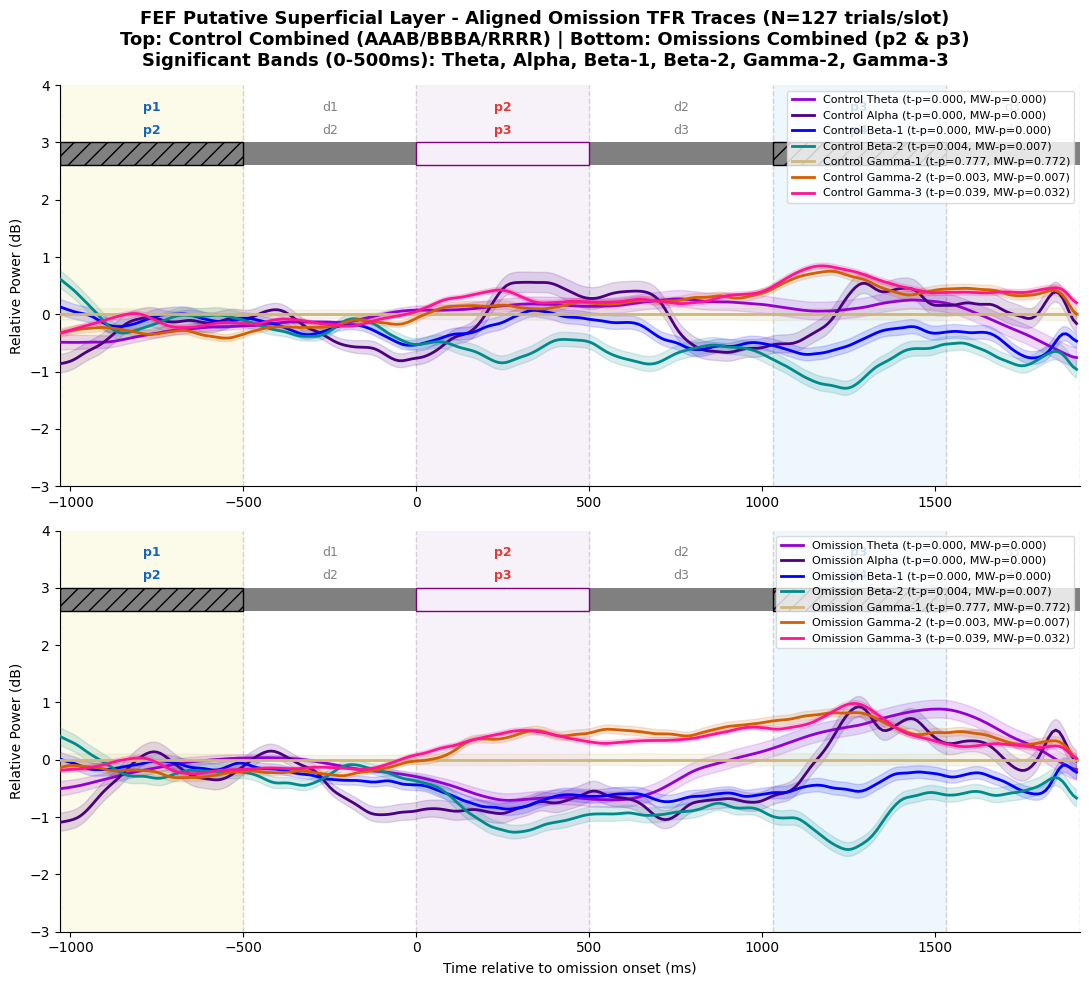

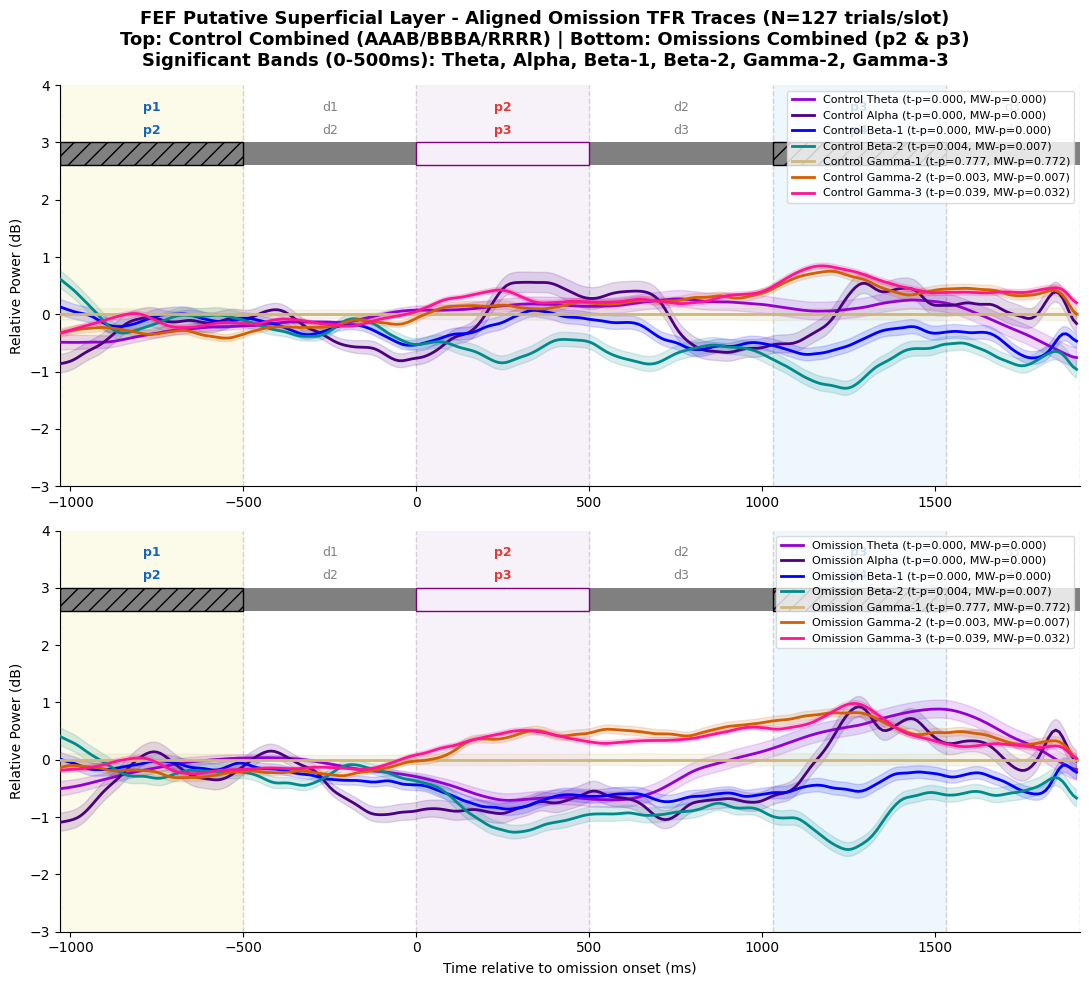

In [3]:
# session_specific=True: the jnwb/viz.py `_rec`-suffix filename bug is fixed, so this
# now genuinely restricts the TFR files to NWB_PATH's own session (not pooled across
# every session that happens to have this area on disk).
result_sup = session.lfp_tfr_trace_suite_omission(area=AREA, layer='superficial', session_specific=True)
print('status:', result_sup['status'])
result_sup['figure']


status: completed


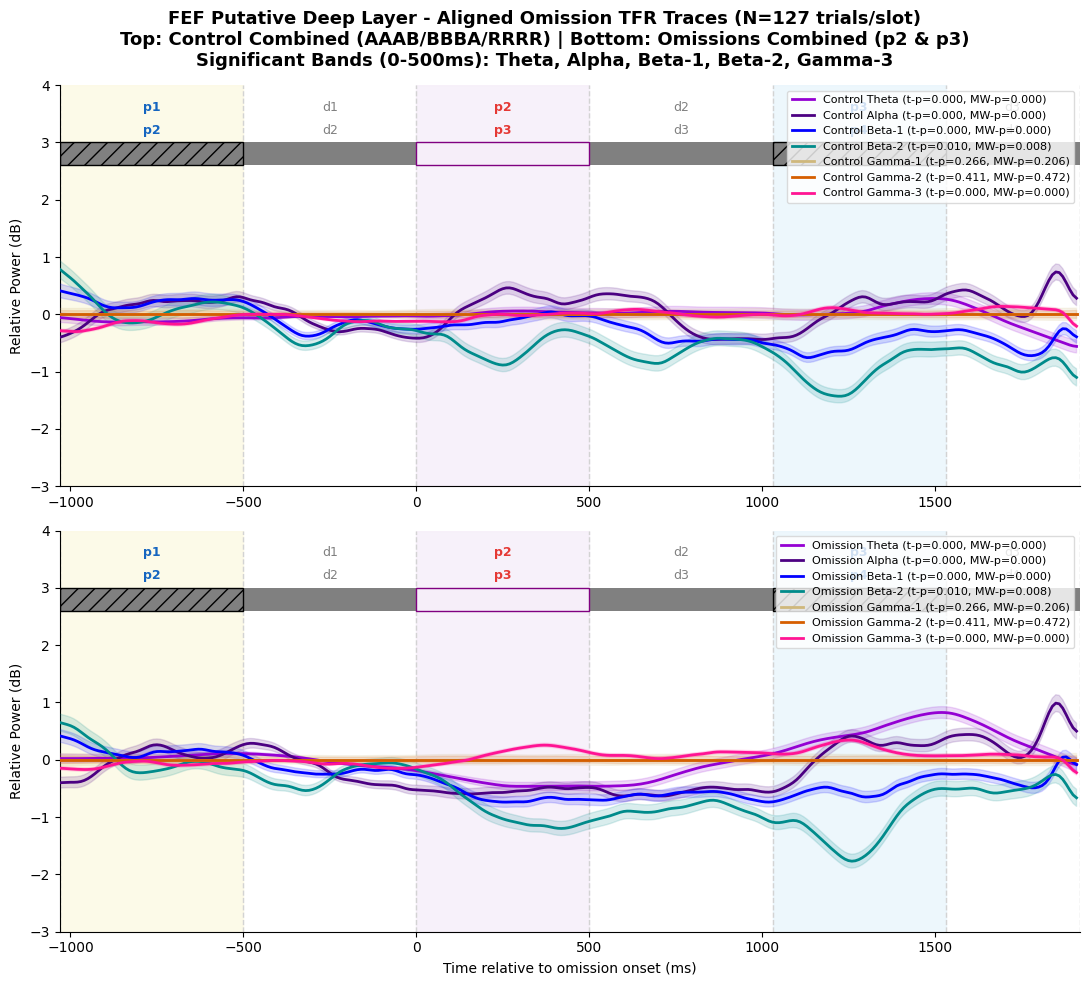

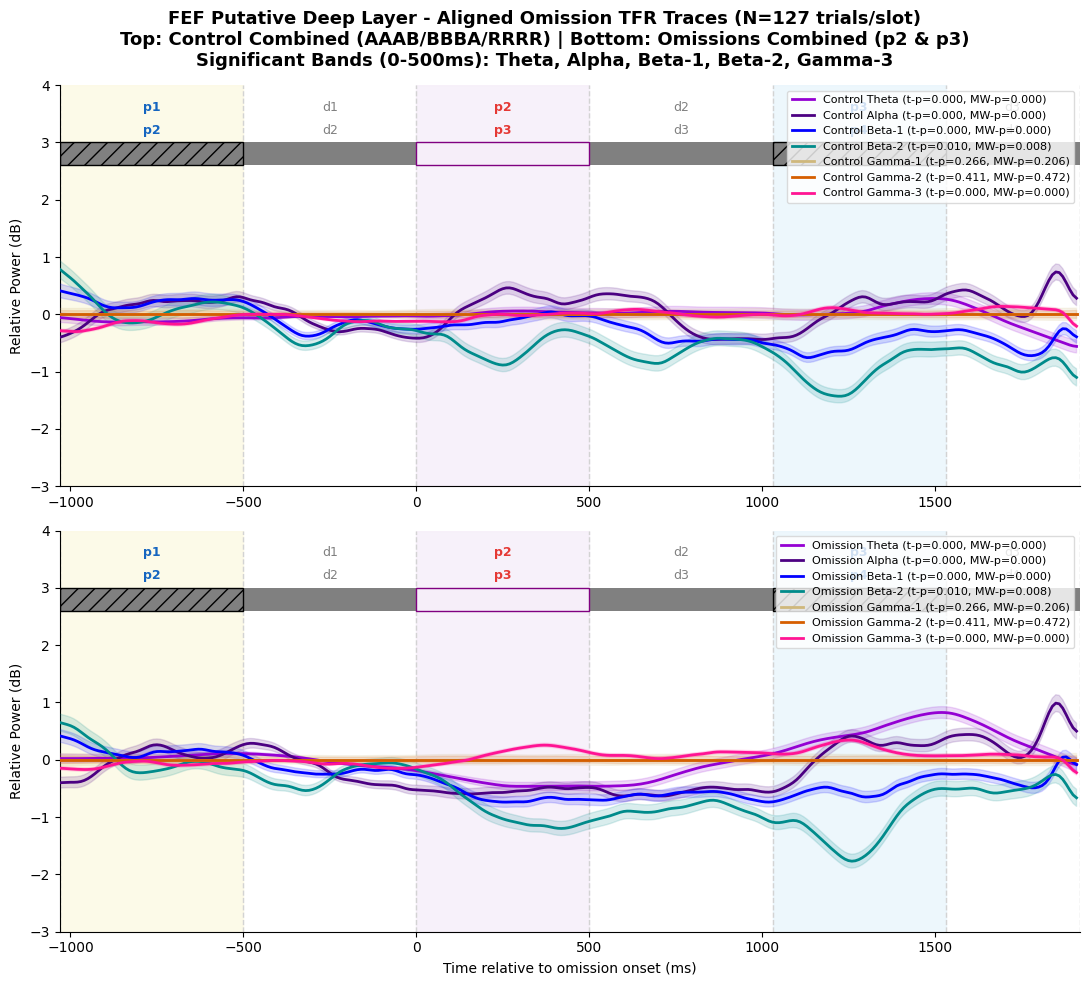

In [4]:
result_deep = session.lfp_tfr_trace_suite_omission(area=AREA, layer='deep', session_specific=True)
print('status:', result_deep['status'])
result_deep['figure']
